# ML From Scratch

Building and comparing linear models, optimizers, and feature representations using only NumPy.

This notebook demonstrates:
- **Regression**: OLS vs Ridge vs Lasso on the Diabetes dataset
- **Classification**: Softmax classifier on handwritten digits
- **Feature Engineering**: Polynomial and RBF mappings for non-linear problems

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from models import LinearRegression, RidgeRegression, LassoRegression, SoftmaxClassifier
from optimizers import SGD, Adam, ProximalGD
from features import PolynomialFeatures, RBFFeatures
from trainer import Trainer, mse, accuracy

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

## Regression: Linear vs Ridge vs Lasso

Comparing unregularized, L2-regularized, and L1-regularized regression on the [Diabetes dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) (442 samples, 10 features).

In [2]:
data = load_diabetes()
X, Y = data.data, data.target[:, None]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

print(f"Train: {X_train.shape[0]} samples, {X_train.shape[1]} features (including bias)")
print(f"Test:  {X_test.shape[0]} samples")

Train: 353 samples, 11 features (including bias)
Test:  89 samples


In [3]:
n_features = X_train.shape[1]
configs = {
    "OLS": (LinearRegression(n_features), SGD(lr=0.01)),
    "Ridge": (RidgeRegression(n_features, alpha=0.1), SGD(lr=0.01)),
    "Lasso": (LassoRegression(n_features, alpha=0.1), ProximalGD(lr=0.01)),
}

trainers = {}
for name, (model, opt) in configs.items():
    trainer = Trainer(model, opt, metric=mse, epochs=200, batch_size=32, seed=42)
    trainer.fit(X_train, Y_train, X_val=X_test, Y_val=Y_test)
    trainers[name] = trainer
    print(f"{name:10s}  Train MSE: {trainer.history['train'][-1]:>8.2f}    Test MSE: {trainer.history['val'][-1]:>8.2f}")

OLS         Train MSE:  2897.11    Test MSE:  2933.00
Ridge       Train MSE:  3099.73    Test MSE:  3174.78
Lasso       Train MSE:  2897.82    Test MSE:  2926.33


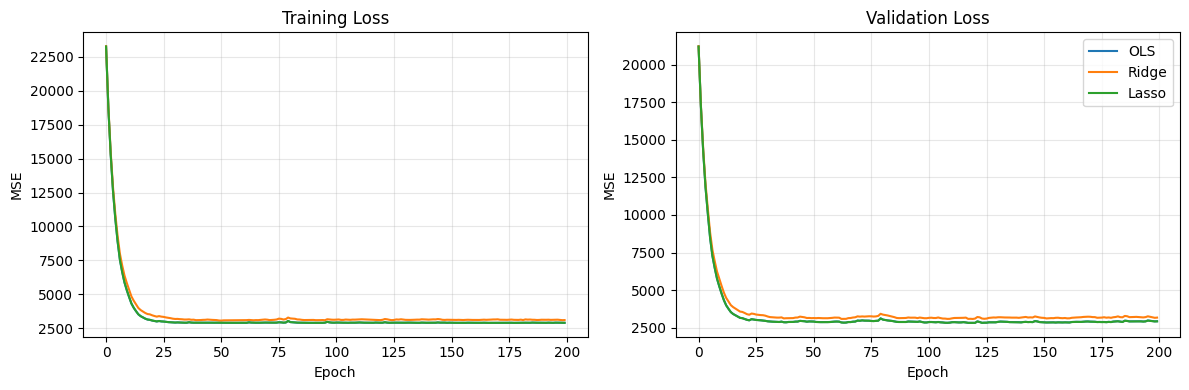

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, trainer in trainers.items():
    axes[0].plot(trainer.history["train"], label=name)
    axes[1].plot(trainer.history["val"], label=name)

axes[0].set(title="Training Loss", xlabel="Epoch", ylabel="MSE")
axes[1].set(title="Validation Loss", xlabel="Epoch", ylabel="MSE")
axes[1].legend()
plt.tight_layout()
plt.show()

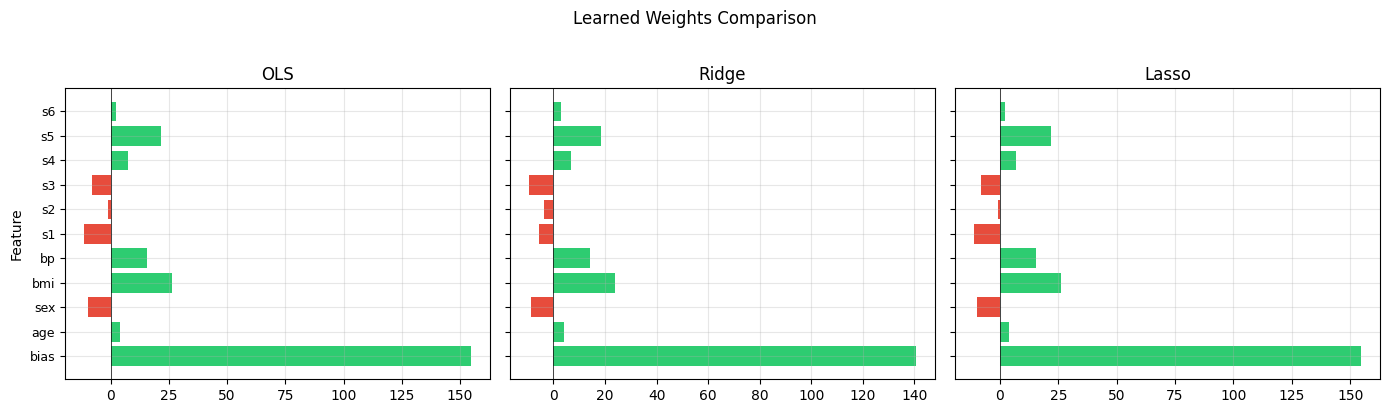

Lasso zeroed out 0/11 weights, demonstrating automatic feature selection


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
feature_names = ["bias"] + list(data.feature_names)

for ax, (name, trainer) in zip(axes, trainers.items()):
    weights = trainer.model.W.flatten()
    colors = ["#2ecc71" if w >= 0 else "#e74c3c" for w in weights]
    ax.barh(range(len(weights)), weights, color=colors)
    ax.set_yticks(range(len(weights)))
    ax.set_yticklabels(feature_names, fontsize=9)
    ax.set_title(name)
    ax.axvline(0, color="black", linewidth=0.5)

axes[0].set_ylabel("Feature")
plt.suptitle("Learned Weights Comparison", y=1.02)
plt.tight_layout()
plt.show()

lasso_w = list(trainers.values())[2].model.W.flatten()
n_zero = np.sum(np.abs(lasso_w) < 1e-3)
print(f"Lasso zeroed out {n_zero}/{len(lasso_w)} weights, demonstrating automatic feature selection")

## Classification: Softmax on Handwritten Digits

Training multinomial logistic regression with the Adam optimizer on sklearn's digits dataset (8x8 pixel images, 10 classes).

In [6]:
digits = load_digits()
X, Y = digits.data, digits.target[:, None]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

n_features = X_train.shape[1]
n_classes = len(np.unique(Y))

print(f"Train: {X_train.shape[0]} samples, {n_features} features, {n_classes} classes")
print(f"Test:  {X_test.shape[0]} samples")

Train: 1437 samples, 65 features, 10 classes
Test:  360 samples


In [7]:
clf_configs = {
    "No Reg": SoftmaxClassifier(n_features, n_classes),
    "L2": SoftmaxClassifier(n_features, n_classes, alpha=1e-3, penalty="l2"),
    "L1": SoftmaxClassifier(n_features, n_classes, alpha=1e-3, penalty="l1"),
}

clf_trainers = {}
for name, model in clf_configs.items():
    opt = Adam(lr=0.01)
    trainer = Trainer(model, opt, metric=accuracy, epochs=100, batch_size=64, seed=42)
    trainer.fit(X_train, Y_train, X_val=X_test, Y_val=Y_test)
    clf_trainers[name] = trainer
    print(f"{name:10s}  Train Acc: {trainer.history['train'][-1]:.3f}    Test Acc: {trainer.history['val'][-1]:.3f}")

No Reg      Train Acc: 1.000    Test Acc: 0.964
L2          Train Acc: 0.998    Test Acc: 0.972
L1          Train Acc: 0.994    Test Acc: 0.967


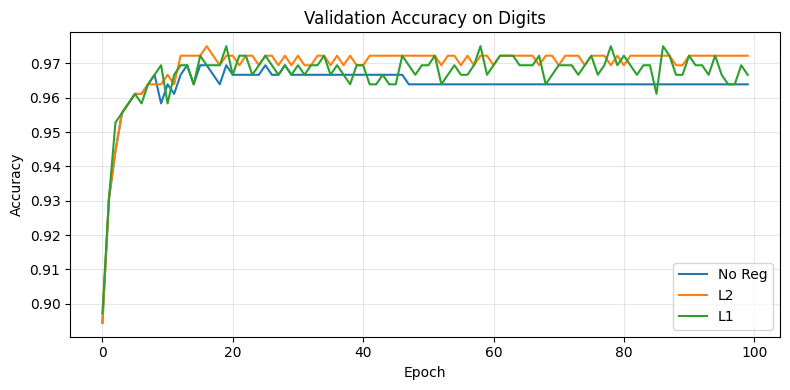

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, trainer in clf_trainers.items():
    ax.plot(trainer.history["val"], label=name)
ax.set(title="Validation Accuracy on Digits", xlabel="Epoch", ylabel="Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

## Non-Linear Feature Engineering

Linear models can only learn linear decision boundaries. By mapping inputs to a richer feature space, we capture non-linear patterns while keeping the model itself linear.

Below we fit **y = sin(x)** using three representations:
- Raw linear features (just x)
- Polynomial features (x, x^2, ..., x^5)
- RBF features (15 Gaussian basis functions)

In [9]:
rng = np.random.default_rng(42)
X_raw = np.sort(rng.uniform(-3, 3, size=(80, 1)), axis=0)
Y_raw = np.sin(X_raw) + 0.15 * rng.normal(size=X_raw.shape)

X_lin = np.hstack([np.ones((80, 1)), X_raw])

poly = PolynomialFeatures(degree=5, cross_terms=False)
X_poly = poly.fit_transform(X_raw)

rbf = RBFFeatures(n_centers=15, sigma=0.8, seed=42)
X_rbf = rbf.fit_transform(X_raw)

results = {}
for name, X_feat in [("Linear", X_lin), ("Polynomial (deg 5)", X_poly), ("RBF (15 centers)", X_rbf)]:
    model = RidgeRegression(X_feat.shape[1], alpha=1e-4)
    opt = Adam(lr=0.01)
    trainer = Trainer(model, opt, metric=mse, epochs=300, batch_size=80, seed=42)
    trainer.fit(X_feat, Y_raw)
    results[name] = (model, X_feat)
    print(f"{name:25s}  Train MSE: {trainer.history['train'][-1]:.4f}")

Linear                     Train MSE: 0.1684
Polynomial (deg 5)         Train MSE: 0.0262
RBF (15 centers)           Train MSE: 0.0214


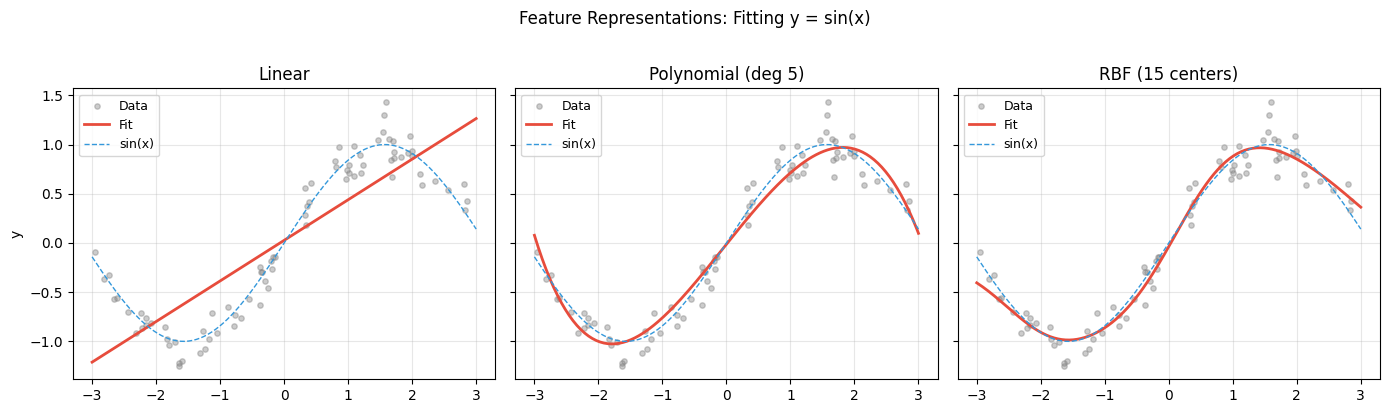

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
X_plot = np.linspace(-3, 3, 200)[:, None]

transforms = {
    "Linear": np.hstack([np.ones((200, 1)), X_plot]),
    "Polynomial (deg 5)": poly.transform(X_plot),
    "RBF (15 centers)": rbf.transform(X_plot),
}

for ax, (name, (model, _)) in zip(axes, results.items()):
    X_p = transforms[name]
    ax.scatter(X_raw, Y_raw, alpha=0.4, s=15, color="gray", label="Data")
    ax.plot(X_plot, model.predict(X_p), color="#e74c3c", linewidth=2, label="Fit")
    ax.plot(X_plot, np.sin(X_plot), "--", color="#3498db", linewidth=1, label="sin(x)")
    ax.set_title(name)
    ax.legend(fontsize=9)

axes[0].set_ylabel("y")
plt.suptitle("Feature Representations: Fitting y = sin(x)", y=1.02)
plt.tight_layout()
plt.show()

## Takeaways

- **Regularization matters.** Ridge (L2) and Lasso (L1) both reduce overfitting compared to plain OLS, but they do so differently — Ridge shrinks all weights uniformly, while Lasso drives irrelevant weights to exactly zero, performing automatic feature selection.
- **Optimizer choice affects convergence.** Adam adapts its learning rate per-parameter using gradient history, making it more robust to poorly scaled features than vanilla SGD. For L1-regularized models, proximal gradient descent outperforms subgradient SGD because it directly enforces sparsity through the soft-thresholding operator.
- **Feature representations extend linear models.** A linear model is only as expressive as its features. Polynomial and RBF mappings allow simple linear models to capture complex non-linear relationships — the model stays linear in the transformed space, but the decision boundary in the original space becomes non-linear.

Every model, optimizer, and feature transform in this project is implemented from scratch using NumPy — no ML framework involved.